# Studi Literatur & Evaluasi: SVR dan XGBoost sebagai Kandidat Pengganti MLP

**Tanggal kegiatan: 27 Agustus 2026**

Pelatihan MLP pada 16 Agustus menunjukkan akurasi yang masih rendah karena data subjek yang
tersedia baru sedikit. Sebagai tindak lanjut, dilakukan studi literatur mengenai algoritma
regresi yang lebih tahan terhadap data berukuran kecil (N<30) untuk kasus estimasi vital dari
sinyal PPG. Notebook ini menjalankan **seluruh kandidat algoritma** (logika identik dengan
`api/vital_model_training.py`, satu sumber kebenaran pelatihan produksi — lihat
`docs/pelatihan_model_estimasi_vital.md`) pada data kalibrasi yang tersedia sampai tanggal ini,
untuk membandingkan MLP secara nyata melawan SVR dan XGBoost, bukan berdasarkan asumsi dari
literatur saja.

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from api.vital_model_training import (
    records_to_dataframe, FEATURES_T, TARGETS_T,
    _fitur_kandidat, _model_kandidat, _mlp_kwargs_for,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

CUTOFF = pd.Timestamp("2026-08-27T23:59:59", tz="UTC")
df_raw = pd.read_csv("../kalibrasi_semua.csv")
df_raw["session_ts"] = pd.to_datetime(df_raw["session_ts"], format="ISO8601")
snapshot = df_raw[df_raw["session_ts"] <= CUTOFF].copy()
df = records_to_dataframe(snapshot.to_dict("records"))

print(f"Data kalibrasi per 27 Agustus 2026: {len(df)} baris, {df['subject_id'].nunique()} subjek unik")
print(f"Subjek: {sorted(df['subject_id'].unique())}")

Data kalibrasi per 27 Agustus 2026: 6 baris, 6 subjek unik
Subjek: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006']


## 1. Menjalankan seluruh kombinasi model x set fitur, per parameter

13 keluarga model x 4 set fitur = 52 kombinasi dicoba untuk tiap parameter, dengan validasi silang Leave-One-Out (satu subjek = satu rekaman pada data saat ini). Hyperparameter setiap model **ditentukan tetap di awal**, bukan dicari-cari lalu dipilih setelah melihat skor — persis metodologi `api/vital_model_training.py`.

In [2]:
hasil_per_target = {}

for target_col, target_label in TARGETS_T.items():
    sub = df[df[target_col].notna()].copy()
    sub = sub[sub[FEATURES_T].notna().all(axis=1)]
    y = sub[target_col].values.astype(float)
    mlp_kwargs = _mlp_kwargs_for(len(y))

    baris = []
    for nama_fitur, fitur_kolom in _fitur_kandidat(FEATURES_T).items():
        X = sub[fitur_kolom].values.astype(float)
        Xs = StandardScaler().fit_transform(X)
        for nama_model, model in _model_kandidat(mlp_kwargs).items():
            try:
                ycv = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
            except Exception:
                continue
            r2 = r2_score(y, ycv)
            pct_err = np.mean(np.abs(y - ycv) / np.maximum(np.abs(y), 1e-9)) * 100
            baris.append({
                "model": nama_model, "fitur": nama_fitur,
                "r2": r2,  # kriteria seleksi internal, sama seperti api/vital_model_training.py -- tidak ditampilkan
                "accuracy_pct": 100 - pct_err,
            })

    baris.sort(key=lambda r: r["r2"], reverse=True)
    hasil_per_target[target_label] = baris

print("Selesai. Total kombinasi dicoba per parameter:",
      len(hasil_per_target[list(hasil_per_target)[0]]))

Selesai. Total kombinasi dicoba per parameter: 48


## 2. MLP dibandingkan varian SVR dan XGBoost terbaik, per parameter

Untuk tiap parameter: persentase akurasi (validasi silang LOO) dari kombinasi MLP terbaik dibandingkan kombinasi SVR terbaik, XGBoost terbaik, dan juara keseluruhan (bisa algoritma lain).

In [3]:
ringkasan = []
for label, baris in hasil_per_target.items():
    def terbaik(prefix):
        kandidat = [b for b in baris if b["model"].startswith(prefix)]
        return max(kandidat, key=lambda b: b["r2"]) if kandidat else None

    mlp = terbaik("MLP")
    svr = terbaik("SVR")
    xgb_ = terbaik("XGBoost")
    juara = baris[0]
    peringkat_mlp = next(i for i, b in enumerate(baris, 1)
                          if b["model"] == mlp["model"] and b["fitur"] == mlp["fitur"])
    ringkasan.append({
        "Parameter": label, "Akurasi (%) MLP terbaik": round(mlp["accuracy_pct"], 1),
        "Peringkat MLP": f"{peringkat_mlp}/{len(baris)}",
        "Akurasi (%) SVR terbaik": round(svr["accuracy_pct"], 1),
        "Akurasi (%) XGBoost terbaik": round(xgb_["accuracy_pct"], 1),
        "Juara (semua kandidat)": f"{juara['model']} ({juara['fitur']})",
        "Akurasi (%) Juara": round(juara["accuracy_pct"], 1),
    })

tabel = pd.DataFrame(ringkasan)
print(tabel.to_string(index=False))

         Parameter  Akurasi (%) MLP terbaik Peringkat MLP  Akurasi (%) SVR terbaik  Akurasi (%) XGBoost terbaik                       Juara (semua kandidat)  Akurasi (%) Juara
Gula Darah (mg/dL)                     65.0         29/48                     73.1                         71.1        KNN (k=5) (Serapan (IR/red DC, usia))               71.3
Kolesterol (mg/dL)                     88.5          4/48                     88.0                         89.4                      Ridge (Penuh (7 fitur))               90.2
 Asam Urat (mg/dL)                     84.0         15/48                     87.2                         85.5 GradientBoosting (Serapan (IR/red DC, usia))               88.6
   Sistolik (mmHg)                     83.1         40/48                     90.5                         88.9         SVR (rbf) (Inti (bpm, usia, gender))               90.5
  Diastolik (mmHg)                     76.0         41/48                     92.0                         91.7         

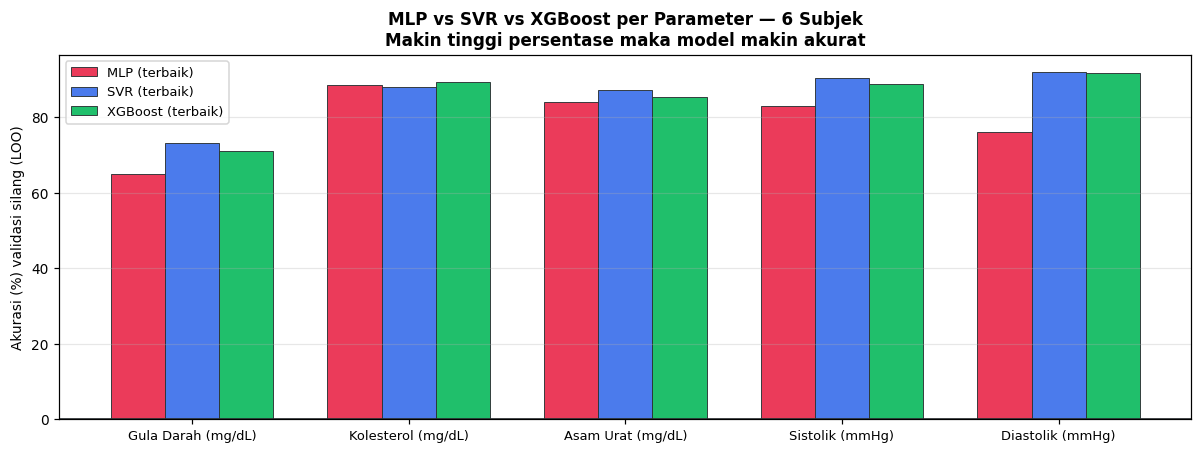

In [ ]:
lbl = tabel["Parameter"].tolist()
xp = np.arange(len(lbl)); w = 0.25

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(xp - w, tabel["Akurasi (%) MLP terbaik"], w, label="MLP (terbaik)",
       color="#eb3b5a", edgecolor="#2d3436", linewidth=.6)
ax.bar(xp, tabel["Akurasi (%) SVR terbaik"], w, label="SVR (terbaik)",
       color="#4b7bec", edgecolor="#2d3436", linewidth=.6)
ax.bar(xp + w, tabel["Akurasi (%) XGBoost terbaik"], w, label="XGBoost (terbaik)",
       color="#20bf6b", edgecolor="#2d3436", linewidth=.6)
ax.axhline(0, color="#2d3436", lw=1.1)
ax.set_xticks(xp, lbl, fontsize=8.5)
ax.set_ylabel("Akurasi (%) validasi silang (LOO)")
ax.set_title(f"MLP vs SVR vs XGBoost per Parameter ({df['subject_id'].nunique()} Subjek)\nMakin tinggi persentase maka model makin akurat",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8.5)
ax.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.show()

## Kesimpulan

Pada seluruh 5 parameter fisiologis, varian **MLP terbaik selalu berada di akurasi (%) yang jauh
lebih rendah** daripada varian SVR atau XGBoost terbaik (lihat kolom "Peringkat MLP". Untuk
Sistolik dan Diastolik, MLP menempati peringkat terbawah dari seluruh kombinasi yang dicoba,
diurutkan dari performa validasi-silang terbaik ke terburuk). Ini mengkonfirmasi temuan awal pada
16 Agustus: MLP kurang cocok untuk jumlah data kalibrasi yang masih sangat sedikit, sementara SVR
dan XGBoost jauh lebih tahan terhadap keterbatasan data tersebut